In [12]:
import os
import cv2
import numpy as np
import random
from tqdm import tqdm
from PIL import Image
import json
import zlib
import base64
from tqdm import tqdm
from io import BytesIO
from torchvision import transforms
from torchvision.utils import save_image
import torch
import numpy as np
from PIL import Image
from io import BytesIO
from torch.utils.data import Dataset
import torchvision.transforms as T
import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image




class CIHPDataset(Dataset):
    def __init__(self, root_dir, target_classes=['face', 'hat', 'head'], target_size=(512, 512)):
        self.root_dir = root_dir
        self.image_dir = os.path.join(root_dir, "img")
        self.mask_dir = os.path.join(root_dir, "mask")
        self.ann_dir = os.path.join(root_dir, "ann")
        self.target_classes = target_classes
        self.target_size = target_size

        # Add this:
        self.image_paths = sorted([
            os.path.join(self.image_dir, fname)
            for fname in os.listdir(self.image_dir)
            if fname.endswith((".jpg", ".png"))
        ])

    def __len__(self):
        return len(self.image_paths)


    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB").resize(self.target_size)
        image_tensor = transforms.ToTensor()(image)
        return image_tensor, image_path



    def _load_mask_from_json(self, ann_path, image_size):
        width, height = image_size
        mask = Image.new('L', (width, height), 0)

        with open(ann_path, 'r') as f:
            data = json.load(f)

        for obj in data.get('objects', []):
            class_title = obj.get('classTitle', '').lower()
            if class_title not in self.target_classes:
                continue

            if obj.get('geometryType') != 'bitmap':
                continue

            bitmap = obj['bitmap']
            origin_x, origin_y = bitmap['origin']
            b64_data = bitmap['data']
            raw = zlib.decompress(base64.b64decode(b64_data))
            submask = Image.open(BytesIO(raw)).convert('L')

            # Paste submask into full image mask
            mask.paste(1, box=(origin_x, origin_y), mask=submask)

        return mask


# --- Config ---
SOURCE_ROOT = "C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training"
OUTPUT_IMG_DIR = "C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training/corrupted"
OUTPUT_MASK_DIR = "C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training/corrupted_mask"
ANNOTATION_DIR = "C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training/ann"
TARGET_SIZE = (512, 512)
FACE_CLASS = 1

# --- Config ---
SOURCE_ROOT = "C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training"
OUTPUT_IMG_DIR = os.path.join(SOURCE_ROOT, "corrupted")
OUTPUT_MASK_DIR = os.path.join(SOURCE_ROOT, "corrupted_mask")
ANNOTATION_DIR = os.path.join(SOURCE_ROOT, "ann")
TARGET_SIZE = (512, 512)
CLASS_MAP = {"face": 1, "hat": 2, "head": 3}
FACE_CLASS = CLASS_MAP["face"]

os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
os.makedirs(OUTPUT_MASK_DIR, exist_ok=True)

to_tensor = transforms.ToTensor()

# --- Mask creation from CIHP-style JSON ---
def build_mask_from_json(json_path, target_size=(512, 512), class_map={'face': 1, 'hat': 2, 'head': 3}):
    width, height = target_size
    mask = Image.new('L', (width, height), 0)

    with open(json_path, 'r') as f:
        data = json.load(f)

    for obj in data.get('objects', []):
        class_title = obj.get('classTitle', '').lower()
        if class_title not in class_map:
            continue

        if obj.get('geometryType') != 'bitmap':
            continue

        bitmap = obj['bitmap']
        origin_x, origin_y = bitmap['origin']
        b64_data = bitmap['data']
        raw = zlib.decompress(base64.b64decode(b64_data))
        submask = Image.open(BytesIO(raw)).convert('L')

        # --- Get original size of the image for scaling
        original_w = data.get('size', {}).get('width', submask.width + origin_x)
        original_h = data.get('size', {}).get('height', submask.height + origin_y)

        scale_x = width / original_w
        scale_y = height / original_h

        # --- Resize submask
        new_w = int(submask.width * scale_x)
        new_h = int(submask.height * scale_y)
        submask_resized = submask.resize((new_w, new_h), resample=Image.NEAREST)

        # --- Adjust origin
        new_origin_x = int(origin_x * scale_x)
        new_origin_y = int(origin_y * scale_y)

        # --- Binarize and assign class ID
        submask_bin = (np.array(submask_resized) > 0).astype(np.uint8) * class_map[class_title]
        submask_pil = Image.fromarray(submask_bin, mode='L')

        # --- Paste directly (without anti-aliased transparency)
        mask.paste(submask_pil, box=(new_origin_x, new_origin_y))

    return np.array(mask, dtype=np.uint8)


# --- Config ---
SOURCE_ROOT = "C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training"
ANNOTATION_DIR = os.path.join(SOURCE_ROOT, "ann")
IMAGE_DIR = os.path.join(SOURCE_ROOT, "img")
OUTPUT_IMG_DIR = os.path.join(SOURCE_ROOT, "corrupted")
OUTPUT_MASK_DIR = os.path.join(SOURCE_ROOT, "corrupted_mask")
TARGET_SIZE = (512, 512)
CLASS_MAP = {'face': 1, 'hat': 2, 'head': 3}
FACE_CLASS = CLASS_MAP['face']

os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
os.makedirs(OUTPUT_MASK_DIR, exist_ok=True)

# --- Transform ---
to_tensor = transforms.ToTensor()

# --- Helper: Corrupt face regions ---
import cv2
import cv2
import numpy as np

import cv2
import numpy as np

import cv2
import numpy as np

import cv2
import numpy as np

def corrupt_face_region(img_np, raw_mask_np):
    """
    Applies strong blur + optional occlusion to face/head/hat region from raw grayscale mask.
    - img_np: original image, shape (H, W, 3)
    - raw_mask_np: raw mask image, shape (H, W), 0–255 or class values
    """

    # Binarize mask (anything non-zero = target)
    face_mask = (raw_mask_np > 0).astype(np.uint8)

    if face_mask.sum() == 0:
        return img_np  # Nothing to do

    corrupted = img_np.copy()

    # Apply strong blur to entire image
    blurred = cv2.GaussianBlur(corrupted, (11, 11), sigmaX=15)

    # Broadcast mask to 3 channels
    face_mask_3c = np.repeat(face_mask[:, :, None], 3, axis=2)

    # Apply blur to masked region
    corrupted = np.where(face_mask_3c == 1, blurred, corrupted)

    # Optional occlusions
    ys, xs = np.where(face_mask == 1)
    if len(xs) > 0 and len(ys) > 0 and np.random.rand() < 0.8:
        xmin, xmax = xs.min(), xs.max()
        ymin, ymax = ys.min(), ys.max()
        num_boxes = np.random.randint(2, 5)

        for _ in range(num_boxes):
            box_w = np.random.randint(10, max(20, (xmax - xmin) // 2))
            box_h = np.random.randint(10, max(20, (ymax - ymin) // 2))

            if xmax - box_w + 1 <= xmin or ymax - box_h + 1 <= ymin:
                continue

            box_x = np.random.randint(xmin, xmax - box_w + 1)
            box_y = np.random.randint(ymin, ymax - box_h + 1)

            if np.random.rand() < 0.5:
                cv2.rectangle(corrupted, (box_x, box_y), (box_x + box_w, box_y + box_h), (0, 0, 0), -1)
            else:
                noise = np.random.randint(0, 256, (box_h, box_w, 3), dtype=np.uint8)
                corrupted[box_y:box_y + box_h, box_x:box_x + box_w] = noise

    return corrupted




# --- Main Corruption Loop ---
image_paths = sorted([
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
    if f.endswith(('.jpg', '.png'))
])

for image_path in tqdm(image_paths, desc="Generating corrupted CIHP"):
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    ann_path = os.path.join(ANNOTATION_DIR, base_name + ".jpg.json")

    if not os.path.exists(ann_path):
        print(f"❌ Missing annotation: {ann_path}")
        continue

    image = Image.open(image_path).convert("RGB").resize(TARGET_SIZE)
    image_tensor = to_tensor(image)
    image_np = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    mask_np = np.zeros(TARGET_SIZE[::-1], dtype=np.uint8)  # H, W

    with open(ann_path, "r") as f:
        ann_data = json.load(f)

    for obj in ann_data.get("objects", []):
        label = obj.get("classTitle", "").lower()
        if label not in CLASS_MAP:
            continue
        if obj.get("geometryType") != "bitmap":
            continue

        bitmap = obj["bitmap"]
        origin_x, origin_y = bitmap["origin"]
        compressed_data = base64.b64decode(bitmap["data"])
        png_bytes = zlib.decompress(compressed_data)
        mask_img = Image.open(BytesIO(png_bytes)).convert("L")
        binary = (np.array(mask_img) > 0).astype(np.uint8)

        # Compute destination coordinates
        y1, y2 = origin_y, origin_y + binary.shape[0]
        x1, x2 = origin_x, origin_x + binary.shape[1]

        # Clip to valid bounds
        y1_clip, y2_clip = max(0, y1), min(mask_np.shape[0], y2)
        x1_clip, x2_clip = max(0, x1), min(mask_np.shape[1], x2)

        # Skip if nothing remains after clipping
        if y2_clip <= y1_clip or x2_clip <= x1_clip:
            continue

        # Adjust the crop of the mask to fit
        crop_y1, crop_y2 = y1_clip - y1, y2_clip - y1
        crop_x1, crop_x2 = x1_clip - x1, x2_clip - x1
        mask_crop = binary[crop_y1:crop_y2, crop_x1:crop_x2]

        # Only update where mask_crop == 1
        mask_np[y1_clip:y2_clip, x1_clip:x2_clip] = np.where(
            mask_crop == 1,
            CLASS_MAP[label],
            mask_np[y1_clip:y2_clip, x1_clip:x2_clip]
        )



    mask_np = build_mask_from_json(ann_path, TARGET_SIZE, class_map=CLASS_MAP)
    corrupted_img = corrupt_face_region(image_np, mask_np)
    out_name = base_name + ".png"
    save_image(to_tensor(corrupted_img), os.path.join(OUTPUT_IMG_DIR, out_name))

    Image.fromarray(mask_np).save(os.path.join(OUTPUT_MASK_DIR, out_name))

print("✅ Corrupted images and annotation-based masks saved.")






Generating corrupted CIHP:  18%|█▊        | 5068/28280 [09:39<44:13,  8.75it/s]  


KeyboardInterrupt: 

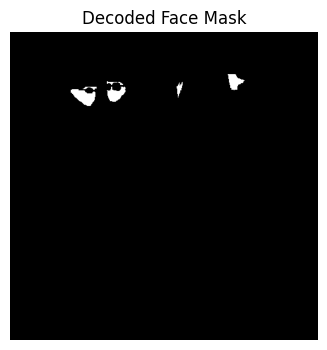

In [4]:
import os
import json
import numpy as np
from PIL import Image
import base64
import zlib
import matplotlib.pyplot as plt

# --- Config ---
annotation_path = "C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training/ann/0000008.jpg.json"
target_size = (512, 512)
FACE_CLASS_TITLE = "face"

# --- Load Annotation ---
with open(annotation_path, "r") as f:
    ann_data = json.load(f)

h, w = ann_data["size"]["height"], ann_data["size"]["width"]
full_mask = np.zeros((h, w), dtype=np.uint8)


import io

# --- Decode and extract masks ---
for obj in ann_data["objects"]:
    if obj.get("classTitle") != FACE_CLASS_TITLE:
        continue

    if obj["geometryType"] != "bitmap":
        continue

    bitmap = obj["bitmap"]
    origin_x, origin_y = bitmap["origin"]
    compressed_data = base64.b64decode(bitmap["data"])
    png_bytes = zlib.decompress(compressed_data)

    # Load the bitmap as an image
    mask_img = Image.open(io.BytesIO(png_bytes)).convert("L")  # 'L' = grayscale
    mask_arr = np.array(mask_img)
    mask = (mask_arr > 0).astype(np.uint8)

    # Place the mask in the correct location
    y1, y2 = origin_y, origin_y + mask.shape[0]
    x1, x2 = origin_x, origin_x + mask.shape[1]
    full_mask[y1:y2, x1:x2] = np.maximum(full_mask[y1:y2, x1:x2], mask)


# --- Resize and visualize ---
mask_resized = Image.fromarray(full_mask * 255).resize(target_size, Image.NEAREST)

plt.figure(figsize=(8, 4))
plt.imshow(mask_resized, cmap='gray')
plt.title("Decoded Face Mask")
plt.axis("off")
plt.show()
